Multimodal Brain Tumor Classifier 

This multimodal fusion model combines complementary information from MRI and CT scans to improve brain tumor detection. Instead of training a new end‑to‑end model from scratch, it leverages pre‑trained unimodal networks (MRI two‑stage binary classifier and CT correlation model) and performs late (feature‑level) fusion by concatenating deep features from both modalities.

### Code Structure

1. Configuration and Styling 
2. CT Model Reconstruction – 
3. Fusion Model – a new model is built that.
4. Unpaired Data Generator – a custom Keras Sequence that:
5. Training 
6. Evaluation & Visualisation 

### Outputs

- Model: Saved as fusion_model.keras in ./Saved_models/.
- Figures: Stored in ./Results/Fusion_figures/ (PNG and PDF formats) including:
- Metrics: Metrics saved as .ipk files. 

In [9]:
import os
import numpy as np
import tensorflow as tf
import random
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
from math import pi
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import cv2
import seaborn as sns
import matplotlib.cm as cm


  MULTIMODAL LATE FUSION PIPELINE
  MRI (Stage-1 CNN) + CT (CLM)  →  Binary Classification

[1/6] Loading pre-trained models...
  MRI stage-1 loaded.
  MRI stage-2 loaded.
  CT CLM loaded.

[2/6] Creating feature extractors...
  MRI extractor → fc3 (256-d)
  CT  extractor → ann_45 (45-d)

[3/6] Building fusion model...


Model: "Multimodal_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ MRI_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CT_input            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MRI_feature_extrac… │ (None, 256)       │  3,904,352 │ MRI_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CT_feature_extract… │ (None, 45)        │    431,737 │ CT_input[0][0]    │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_features     │ (None, 301)       │          0 │ MRI_feature_extr… │
│ (Concatenate)       │                   │            │ CT_feature_extra… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_joint_1 (Dense)  │ (None, 128)       │     38,656 │ concat_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ fc_joint_1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_joint_2 (Dense)  │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ fc_joint_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │        130 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,383,643 (16.72 MB)

 Trainable params: 47,298 (184.76 KB)

 Non-trainable params: 4,336,345 (16.54 MB)


[4/6] Preparing unpaired multimodal generators...
  [TRAIN] 14510 MRI + 3241 CT → 14510 pairs
  [VAL] 3113 MRI + 695 CT → 3113 pairs
  [TEST] 3113 MRI + 696 CT → 3113 pairs


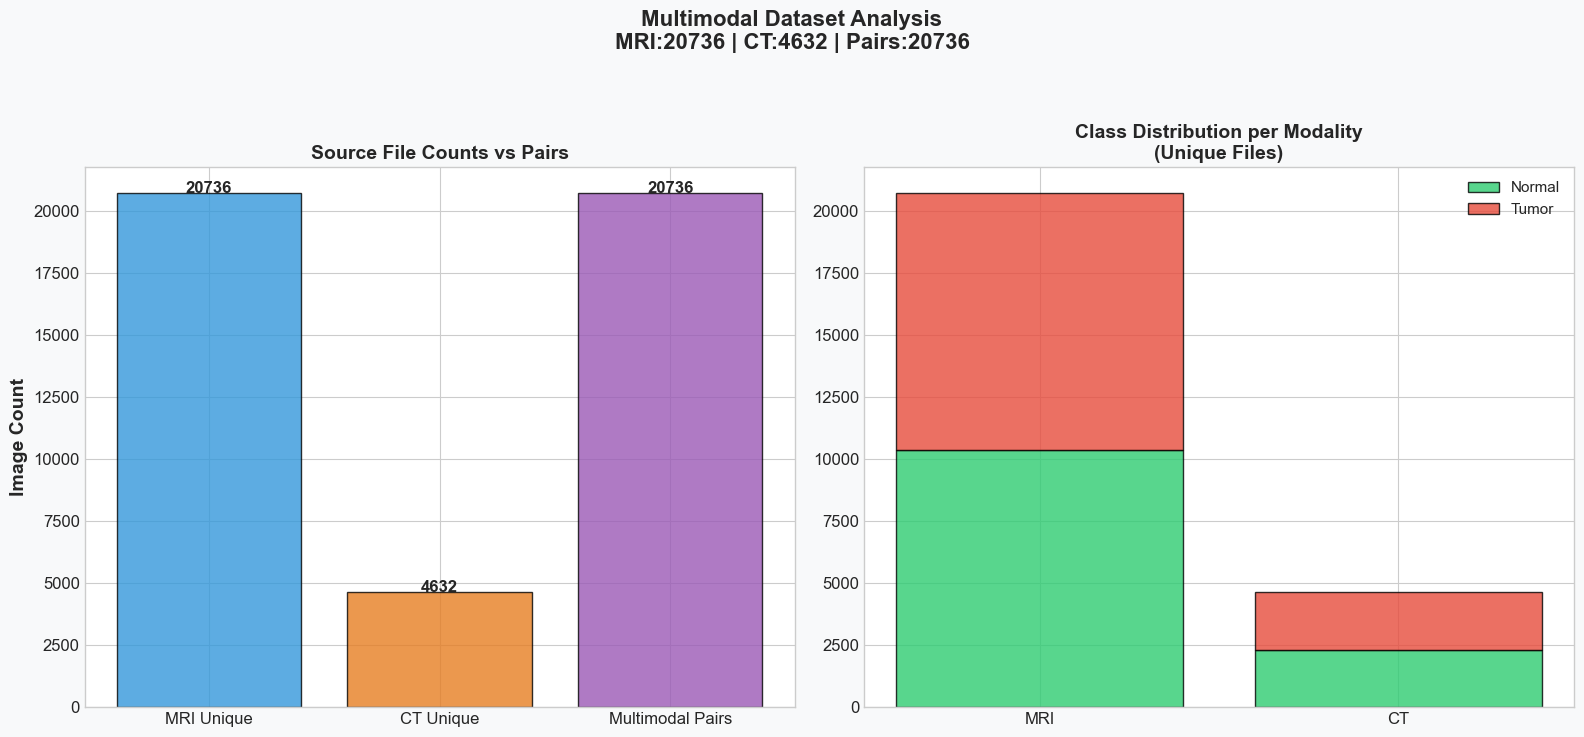

  Data distribution chart saved.

[5/6] Training fusion model...
Epoch 1/3
4837/4837 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - accuracy: 0.8536 - loss: 0.3371 - val_accuracy: 0.9949 - val_loss: 0.1166 - learning_rate: 1.0000e-04
Epoch 2/3
4837/4837 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9065 - loss: 0.2048 - val_accuracy: 0.9647 - val_loss: 0.1535 - learning_rate: 1.0000e-04
Epoch 3/3
4837/4837 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.9374 - loss: 0.1476 - val_accuracy: 0.9814 - val_loss: 0.0951 - learning_rate: 1.0000e-04
  Fusion model saved → ./Saved_models/fusion_model.keras


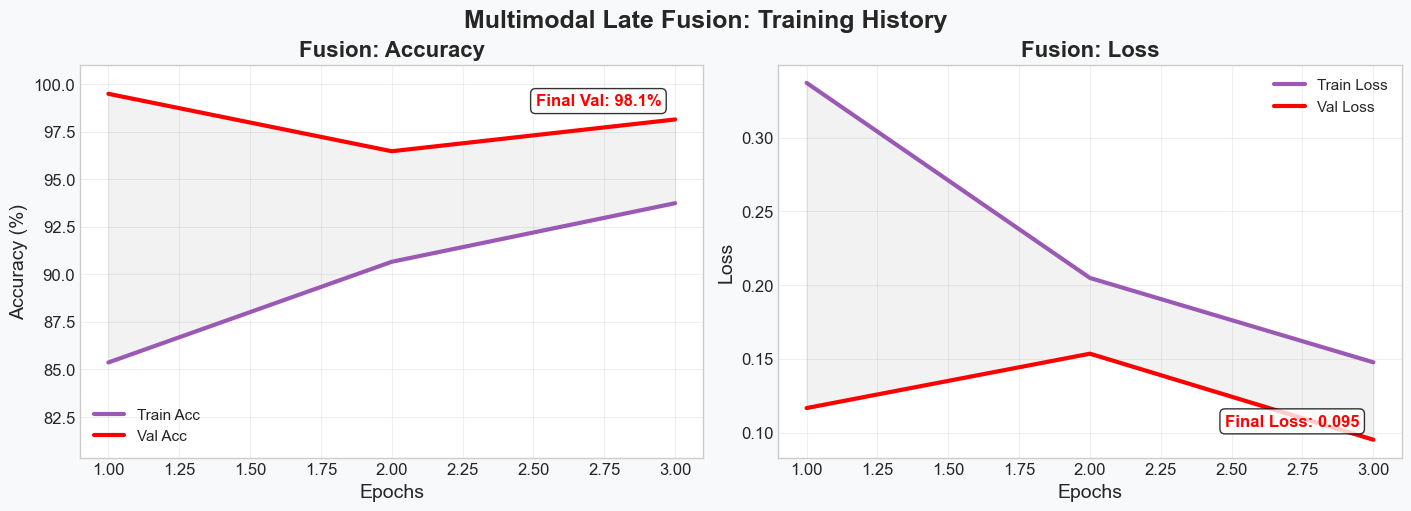

  Training curves saved.

[6/6] Evaluating on test set...


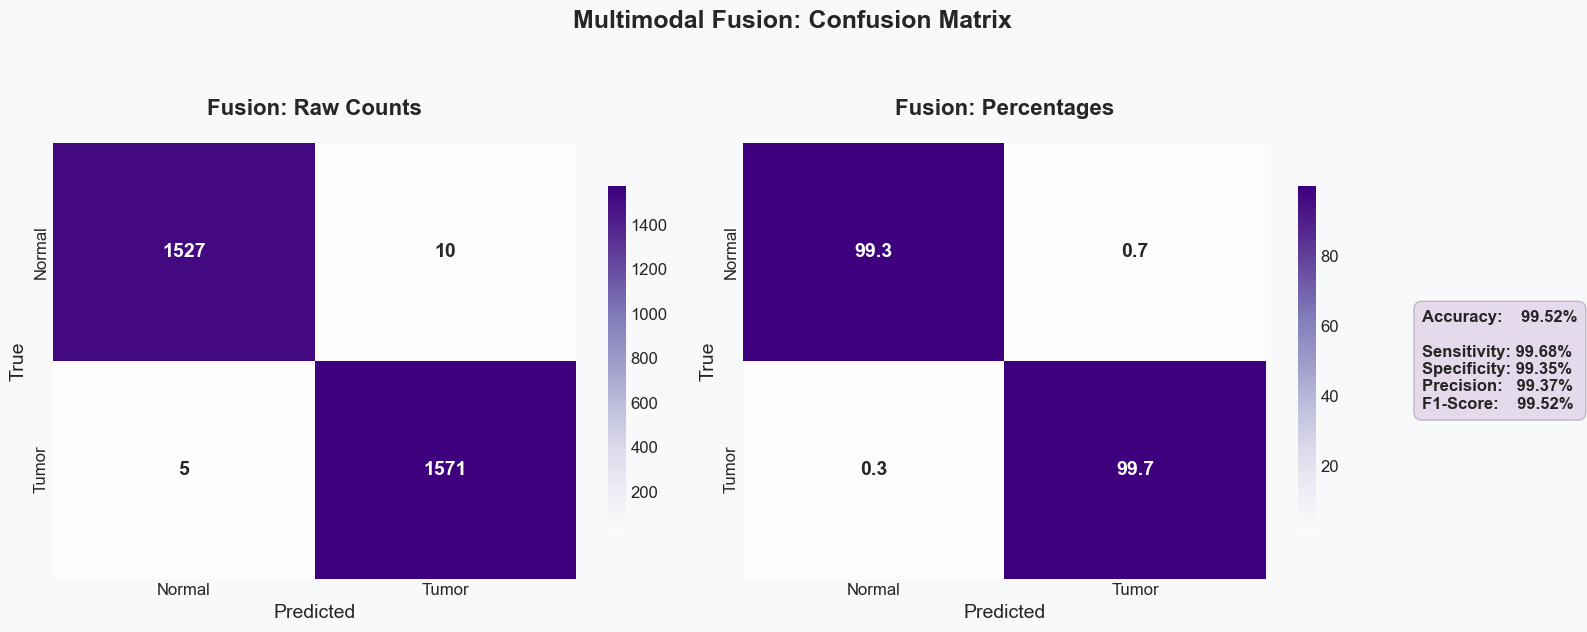

  Confusion matrix saved.


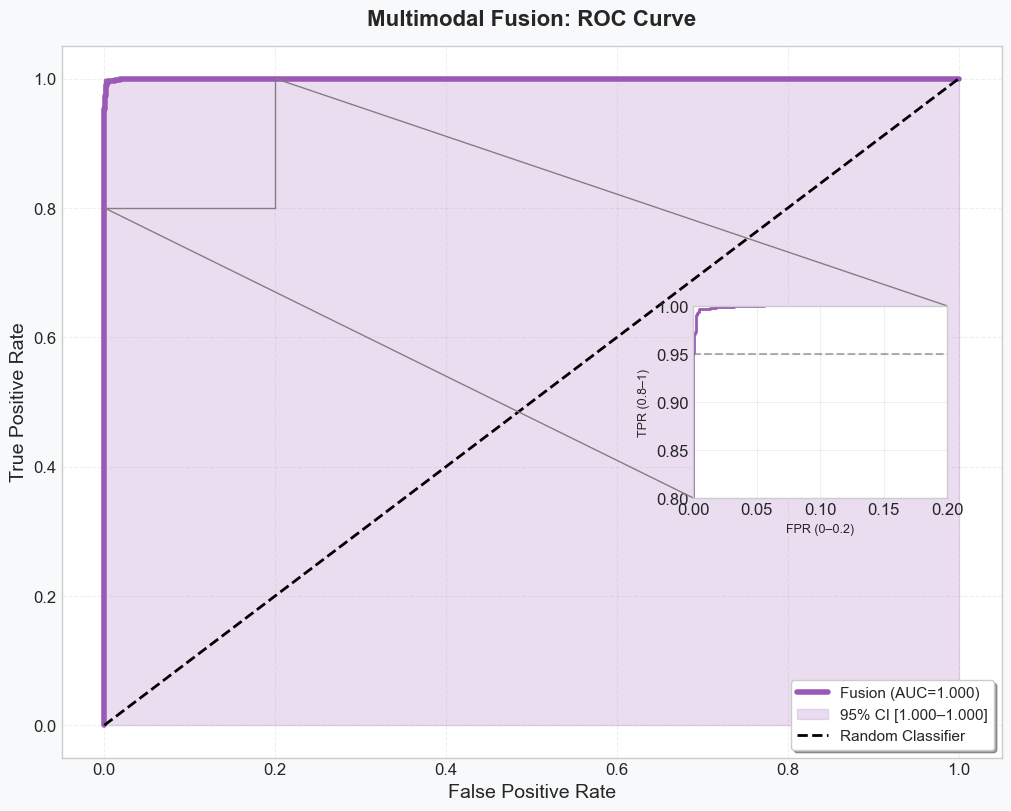

  ROC curve saved.

Loading unimodal baseline scores...
  MRI    : ['99.4', '99.5', '99.3', '99.4', '100.0']
  CT     : ['89.1', '89.5', '87.9', '88.7', '94.7']
  Fusion : ['99.5', '99.4', '99.7', '99.5', '100.0']


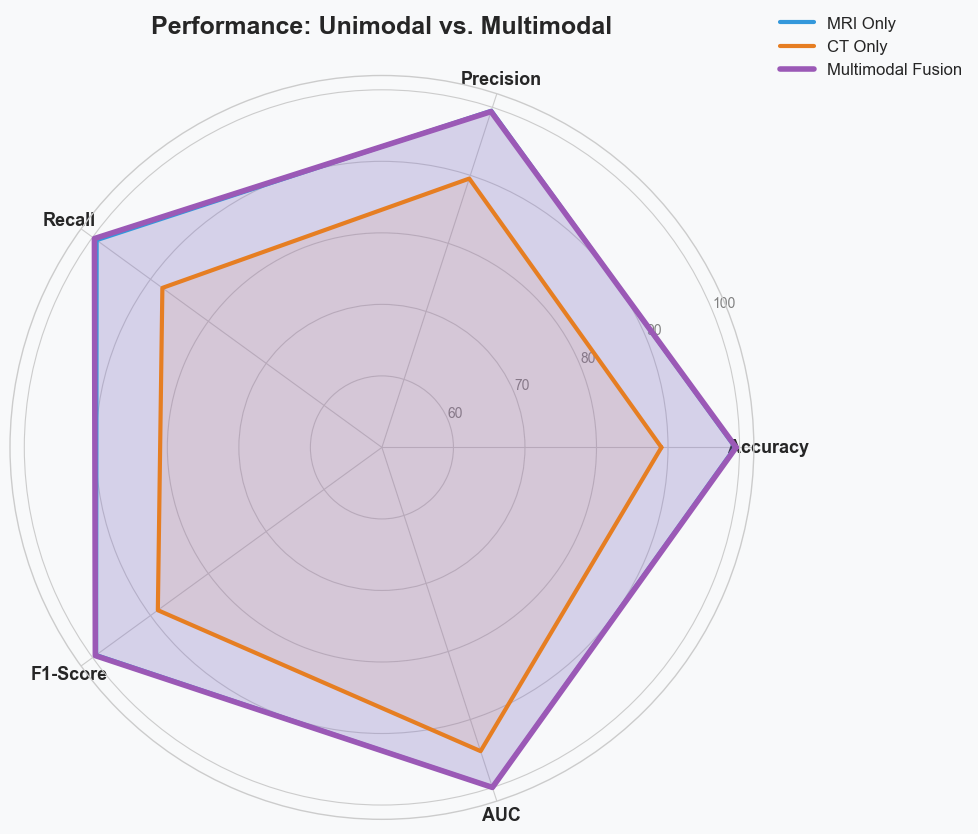

  Radar chart saved.


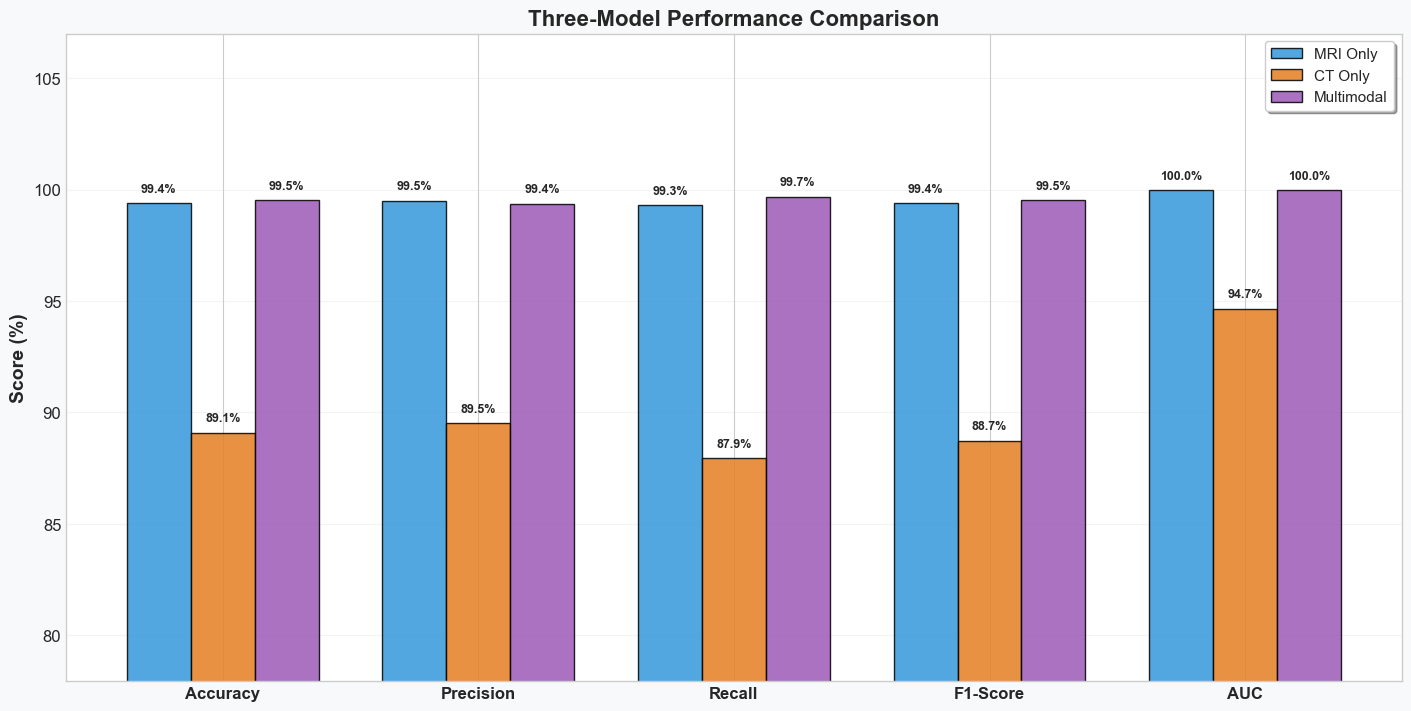

  Three-model comparison chart saved.

  McNemar (Fusion vs MRI): p=0.6069 (not significant at α=0.05)

--- Special Evaluation: Early-Stage & Low-Contrast Detection ---


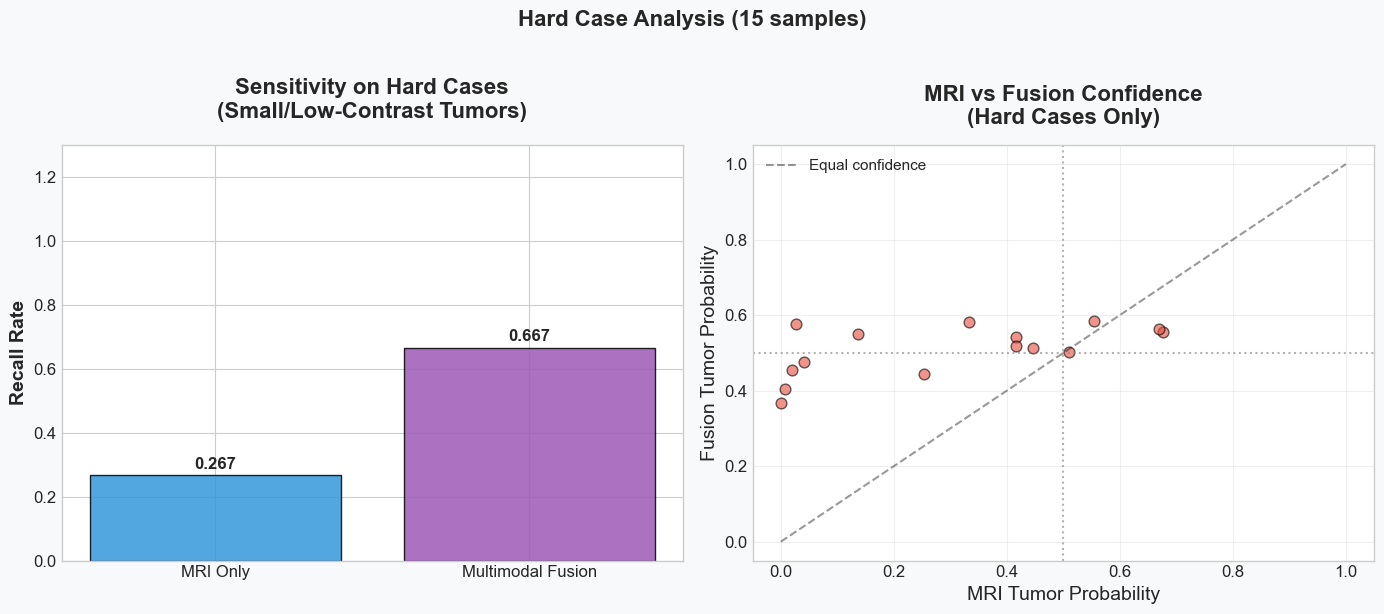

  Hard cases:15 | MRI:0.267 | Fusion:0.667

  CLASSIFICATION REPORT — FUSION MODEL
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      1537
       Tumor       0.99      1.00      1.00      1576

    accuracy                           1.00      3113
   macro avg       1.00      1.00      1.00      3113
weighted avg       1.00      1.00      1.00      3113


  Results saved → ./Saved_models/multimodal_results.pkl

  MULTIMODAL FUSION PIPELINE COMPLETED
  Figures → ./Results/Fusion_figures
  Model   → ./Saved_models/fusion_model.keras


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Multimodal_Fusion.py
Las capas custom estan definidas inline con package="CTClassifier",
igual que en CT_Classifier.ipynb. Keras las empareja por nombre,
no por archivo de origen. No se necesita importar CT_Classifier.
"""
 
import os, random, pickle
import numpy as np
import tensorflow as tf
from math import pi
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import warnings; warnings.filterwarnings('ignore')
 
 
# ============================================================================
# CUSTOM LAYERS  — package="CTClassifier" debe coincidir con CT_Classifier.ipynb
# ============================================================================
 
@register_keras_serializable(package="CTClassifier")
class PatchExtractorLayer(tf.keras.layers.Layer):
    def __init__(self, patch_size=28, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
    def call(self, inputs):
        return tf.image.extract_patches(
            images=inputs,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1], padding='VALID')
    def get_config(self):
        cfg = super().get_config(); cfg.update({"patch_size": self.patch_size}); return cfg
 
@register_keras_serializable(package="CTClassifier")
class PatchStatisticsLayer(tf.keras.layers.Layer):
    def call(self, pf):
        p_min  = tf.reduce_min(pf,  axis=-1, keepdims=True)
        p_max  = tf.reduce_max(pf,  axis=-1, keepdims=True)
        p_sum  = tf.reduce_sum(pf,  axis=-1, keepdims=True)
        p_mean = tf.reduce_mean(pf, axis=-1, keepdims=True)
        p_std  = tf.math.reduce_std(pf, axis=-1, keepdims=True)
        sf = tf.sort(pf, axis=-1); n = tf.shape(pf)[-1]
        p_med = tf.reduce_mean(sf[:, :, n//4:3*n//4], axis=-1, keepdims=True)
        return tf.concat([p_min,p_max,p_sum,p_mean,p_std,p_med], axis=-1)
    def get_config(self): return super().get_config()
 
 
# ============================================================================
# CONFIGURATION
# ============================================================================
 
plt.style.use('seaborn-v0_8-whitegrid'); sns.set_palette("husl")
plt.rcParams.update({'figure.figsize':(12,8),'font.size':12,
                     'axes.labelsize':14,'axes.titlesize':16,'legend.fontsize':11})
 
CONFIG = {
    'MRI_STAGE1_PATH': './Saved_models/MRI_stage1_binary_model.keras',
    'MRI_STAGE2_PATH': './Saved_models/MRI_stage2_multiclass_model.keras',
    'CT_MODEL_PATH':   './Saved_models/ct_correlation_model.keras',
    'MRI_DATA_ROOT':   '/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/MRI',
    'CT_DATA_ROOT':    '/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/CT',
    'FUSION_INPUT_SHAPE_MRI': (224, 224, 4),
    'FUSION_INPUT_SHAPE_CT':  (224, 224, 4),
    'NUM_CLASSES':   2,
    'BATCH_SIZE':    3, #16
    'EPOCHS':        3, #50
    'LEARNING_RATE': 1e-4,
    'FUSION_MODEL_SAVE_PATH': './Saved_models/fusion_model.keras',
    'FIGURE_PATH':  './Results/Fusion_figures',
    'RESULTS_PATH': './Results',
}
 
CLASS_NAMES        = ['Normal', 'Tumor']
STAGE2_CLASS_NAMES = ['Meningioma', 'Glioma', 'Pituitary']
COLORS = {'mri':'#3498DB','ct':'#E67E22','multimodal':'#9B59B6',
          'normal':'#2ECC71','tumor':'#E74C3C','background':'#F8F9FA',
          'meningioma':'#3498DB','glioma':'#9B59B6','pituitary':'#E67E22'}
 
os.makedirs(CONFIG['FIGURE_PATH'],  exist_ok=True)
os.makedirs(CONFIG['RESULTS_PATH'], exist_ok=True)
 
 
# ============================================================================
# UNPAIRED DATA GENERATOR
# ============================================================================
 
class UnpairedMultimodalGenerator(tf.keras.utils.Sequence):
    def __init__(self, mri_root, ct_root, split='train', batch_size=16,
                 mri_shape=(224,224,4), ct_shape=(224,224,4), shuffle=True):
        self.mri_root=os.path.join(mri_root,split); self.ct_root=os.path.join(ct_root,split)
        self.split=split; self.batch_size=batch_size
        self.mri_shape=mri_shape; self.ct_shape=ct_shape; self.shuffle=shuffle
        self.mri_raw_counts={0:0,1:0}; self.ct_raw_counts={0:0,1:0}; self.pairs=[]
        self._build_pseudo_pairs(); self.on_epoch_end()
 
    def _get_files_by_class(self, root):
        cm={0:[],1:[]}
        for r,_,files in os.walk(root):
            for f in files:
                if f.endswith('.npy'):
                    p=os.path.join(r,f); cm[0 if 'normal' in p.lower() else 1].append(p)
        return cm
 
    def _build_pseudo_pairs(self):
        mc=self._get_files_by_class(self.mri_root); cc=self._get_files_by_class(self.ct_root)
        for label in [0,1]:
            ml=mc[label]; cl=cc[label]
            self.mri_raw_counts[label]=len(ml); self.ct_raw_counts[label]=len(cl)
            if not ml or not cl: print(f"  [Warning] No data class {label} in '{self.split}'"); continue
            random.shuffle(ml); random.shuffle(cl)
            for i in range(max(len(ml),len(cl))):
                self.pairs.append((ml[i%len(ml)], cl[i%len(cl)], label))
        if not self.pairs: raise RuntimeError(f"No pairs for split '{self.split}'.")
        mt=self.mri_raw_counts[0]+self.mri_raw_counts[1]
        ct=self.ct_raw_counts[0]+self.ct_raw_counts[1]
        print(f"  [{self.split.upper()}] {mt} MRI + {ct} CT → {len(self.pairs)} pairs")
 
    def __len__(self): return int(np.ceil(len(self.pairs)/self.batch_size))
 
    def __getitem__(self, idx):
        s=idx*self.batch_size; e=min(s+self.batch_size,len(self.pairs))
        batch=[self.pairs[i] for i in self.indexes[s:e]]
        mb=np.zeros((len(batch),*self.mri_shape),dtype=np.float32)
        cb=np.zeros((len(batch),*self.ct_shape), dtype=np.float32)
        labels=[]
        for i,(mp,cp,label) in enumerate(batch):
            mri=np.load(mp).astype(np.float32); ct=np.load(cp).astype(np.float32)
            if mri.shape[:2]!=self.mri_shape[:2]: mri=tf.image.resize(mri,self.mri_shape[:2]).numpy()
            if ct.shape[:2] !=self.ct_shape[:2]:  ct =tf.image.resize(ct, self.ct_shape[:2]).numpy()
            if mri.max()>1.0: mri=mri/255.0
            if ct.max() >1.0: ct =ct /255.0
            mb[i]=mri; cb[i]=ct; labels.append(label)
        return (mb,cb), to_categorical(labels,num_classes=2)
 
    def on_epoch_end(self):
        self.indexes=np.arange(len(self.pairs))
        if self.shuffle: np.random.shuffle(self.indexes)
 
 
# ============================================================================
# MODEL LOADING
# ============================================================================
 
def load_pretrained_models():
    print("\n[1/6] Loading pre-trained models...")
    for p in [CONFIG['MRI_STAGE1_PATH'], CONFIG['CT_MODEL_PATH']]:
        if not os.path.exists(p): raise FileNotFoundError(p)
 
    mri_stage1=tf.keras.models.load_model(CONFIG['MRI_STAGE1_PATH'],compile=False,safe_mode=False)
    print("  MRI stage-1 loaded.")
 
    mri_stage2=None
    if os.path.exists(CONFIG['MRI_STAGE2_PATH']):
        mri_stage2=tf.keras.models.load_model(CONFIG['MRI_STAGE2_PATH'],compile=False,safe_mode=False)
        print("  MRI stage-2 loaded.")
 
    # PatchExtractorLayer y PatchStatisticsLayer ya registradas arriba
    ct_model=tf.keras.models.load_model(CONFIG['CT_MODEL_PATH'],compile=False,safe_mode=False)
    print("  CT CLM loaded.")
    return mri_stage1, mri_stage2, ct_model
 
 
def create_feature_extractors(mri_stage1, ct_model):
    mri_f=models.Model(inputs=mri_stage1.input,
                       outputs=mri_stage1.get_layer('fc3').output,
                       name="MRI_feature_extractor")
    mri_f.trainable=False; print("  MRI extractor → fc3 (256-d)")
 
    ct_f=models.Model(inputs=ct_model.input,
                      outputs=ct_model.get_layer('ann_45').output,
                      name="CT_feature_extractor")
    ct_f.trainable=False; print("  CT  extractor → ann_45 (45-d)")
    return mri_f, ct_f
 
 
def build_fusion_model(mri_feature, ct_feature):
    mi=layers.Input(shape=CONFIG['FUSION_INPUT_SHAPE_MRI'],name="MRI_input")
    ci=layers.Input(shape=CONFIG['FUSION_INPUT_SHAPE_CT'], name="CT_input")
    concat=layers.Concatenate(name="concat_features")([mri_feature(mi), ct_feature(ci)])
    x=layers.Dense(128,activation='relu',name="fc_joint_1")(concat)
    x=layers.BatchNormalization()(x); x=layers.Dropout(0.5)(x)
    x=layers.Dense(64,activation='relu',name="fc_joint_2")(x); x=layers.Dropout(0.3)(x)
    out=layers.Dense(2,activation='softmax',name="output")(x)
    return models.Model(inputs=[mi,ci],outputs=out,name="Multimodal_Fusion")
 
 
# ============================================================================
# VISUALIZATIONS
# ============================================================================
 
def create_data_distribution_chart(train_gen, val_gen, test_gen):
    gens=[train_gen,val_gen,test_gen]
    mt=sum(g.mri_raw_counts[0]+g.mri_raw_counts[1] for g in gens)
    ct=sum(g.ct_raw_counts[0] +g.ct_raw_counts[1]  for g in gens)
    pt=sum(len(g.pairs) for g in gens)
 
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,7)); fig.patch.set_facecolor(COLORS['background'])
    bars=ax1.bar(['MRI Unique','CT Unique','Multimodal Pairs'],[mt,ct,pt],
                 color=[COLORS['mri'],COLORS['ct'],COLORS['multimodal']],edgecolor='black',alpha=0.8)
    ax1.set_title('Source File Counts vs Pairs',fontsize=14,fontweight='bold')
    ax1.set_ylabel('Image Count',fontweight='bold')
    for bar in bars:
        h=bar.get_height(); ax1.text(bar.get_x()+bar.get_width()/2.,h+1,f'{int(h)}',ha='center',fontweight='bold')
 
    mn=sum(g.mri_raw_counts[0] for g in gens); mtum=sum(g.mri_raw_counts[1] for g in gens)
    cn=sum(g.ct_raw_counts[0]  for g in gens); ctum=sum(g.ct_raw_counts[1]  for g in gens)
    ax2.bar(['MRI','CT'],[mn,cn],label='Normal',color=COLORS['normal'],edgecolor='black',alpha=0.8)
    ax2.bar(['MRI','CT'],[mtum,ctum],bottom=[mn,cn],label='Tumor',color=COLORS['tumor'],edgecolor='black',alpha=0.8)
    ax2.set_title('Class Distribution per Modality\n(Unique Files)',fontsize=14,fontweight='bold'); ax2.legend()
    plt.suptitle(f'Multimodal Dataset Analysis\nMRI:{mt} | CT:{ct} | Pairs:{pt}',fontsize=16,fontweight='bold',y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'],'modality_source_distinction.png'),dpi=300,bbox_inches='tight')
    plt.show(); print("  Data distribution chart saved.")
 
 
def plot_fusion_training_curves(history):
    acc=np.array(history.history['accuracy'])*100; val_acc=np.array(history.history['val_accuracy'])*100
    loss=history.history['loss']; val_loss=history.history['val_loss']
    ep=np.arange(1,len(acc)+1)
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5),constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])
    ax1.plot(ep,acc,color=COLORS['multimodal'],label='Train Acc',lw=3)
    ax1.plot(ep,val_acc,color='red',label='Val Acc',lw=3)
    ax1.fill_between(ep,acc,val_acc,alpha=0.1,color='gray')
    ax1.set(xlabel='Epochs',ylabel='Accuracy (%)'); ax1.set_title('Fusion: Accuracy',fontweight='bold')
    ax1.legend(); ax1.grid(True,alpha=0.3); ax1.set_ylim([min(acc.min(),val_acc.min())-5,101])
    ax1.annotate(f'Final Val: {val_acc[-1]:.1f}%',xy=(ep[-1],val_acc[-1]),xytext=(-10,10),
                 textcoords='offset points',ha='right',bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.8),fontweight='bold',color='red')
    ax2.plot(ep,loss,color=COLORS['multimodal'],label='Train Loss',lw=3)
    ax2.plot(ep,val_loss,color='red',label='Val Loss',lw=3)
    ax2.fill_between(ep,loss,val_loss,alpha=0.1,color='gray')
    ax2.set(xlabel='Epochs',ylabel='Loss'); ax2.set_title('Fusion: Loss',fontweight='bold')
    ax2.legend(); ax2.grid(True,alpha=0.3)
    ax2.annotate(f'Final Loss: {val_loss[-1]:.3f}',xy=(ep[-1],val_loss[-1]),xytext=(-10,10),
                 textcoords='offset points',ha='right',bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.8),fontweight='bold',color='red')
    plt.suptitle('Multimodal Late Fusion: Training History',fontsize=18,fontweight='bold')
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'],'fusion_training_curves.png'),dpi=300)
    plt.show(); print("  Training curves saved.")
 
 
def plot_fusion_confusion_matrix(y_true, y_pred, class_names):
    cm=confusion_matrix(y_true,y_pred); cp=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]*100
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6)); fig.patch.set_facecolor(COLORS['background'])
    for ax,data,fmt,title in [(ax1,cm,'d','Fusion: Raw Counts'),(ax2,cp,'.1f','Fusion: Percentages')]:
        sns.heatmap(data,annot=True,fmt=fmt,cmap='Purples',xticklabels=class_names,yticklabels=class_names,
                    ax=ax,cbar_kws={'shrink':0.8},annot_kws={'size':14,'weight':'bold'})
        ax.set(xlabel='Predicted',ylabel='True'); ax.set_title(title,fontweight='bold',pad=20)
    tn,fp,fn,tp=cm.ravel()
    acc=((tp+tn)/np.sum(cm)); sens=(tp/(tp+fn) if tp+fn>0 else 0); spec=(tn/(tn+fp) if tn+fp>0 else 0)
    prec=(tp/(tp+fp) if tp+fp>0 else 0); f1=(2*prec*sens/(prec+sens) if prec+sens>0 else 0)
    ax2.text(1.3,0.5,f'Accuracy:    {acc*100:.2f}%\n\nSensitivity: {sens*100:.2f}%\nSpecificity: {spec*100:.2f}%\nPrecision:   {prec*100:.2f}%\nF1-Score:    {f1*100:.2f}%',
             transform=ax2.transAxes,fontsize=12,fontweight='bold',verticalalignment='center',
             bbox=dict(boxstyle='round,pad=0.5',facecolor=COLORS['multimodal'],alpha=0.2))
    plt.suptitle('Multimodal Fusion: Confusion Matrix',fontsize=18,fontweight='bold',y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'],'fusion_confusion_matrix.png'),dpi=300,bbox_inches='tight')
    plt.show(); print("  Confusion matrix saved.")
    return acc,sens,spec,prec,f1
 
 
def plot_fusion_roc_curve(y_true, y_pred_proba, n_bootstraps=1000):
    fpr,tpr,_=roc_curve(y_true,y_pred_proba[:,1]); base_auc=auc(fpr,tpr)
    rng=np.random.RandomState(42); ya=np.array(y_true); boots=[]
    for _ in range(n_bootstraps):
        idx=rng.randint(0,len(ya),len(ya))
        if len(np.unique(ya[idx]))<2: continue
        boots.append(roc_auc_score(ya[idx],y_pred_proba[idx,1]))
    ci_lo=np.percentile(boots,2.5); ci_hi=np.percentile(boots,97.5)
    fig,ax=plt.subplots(figsize=(10,8),constrained_layout=True); fig.patch.set_facecolor(COLORS['background'])
    ax.plot(fpr,tpr,color=COLORS['multimodal'],lw=4,label=f'Fusion (AUC={base_auc:.3f})')
    ax.fill_between(fpr,tpr,alpha=0.2,color=COLORS['multimodal'],label=f'95% CI [{ci_lo:.3f}–{ci_hi:.3f}]')
    ax.plot([0,1],[0,1],'k--',lw=2,label='Random Classifier')
    ax.set(xlabel='False Positive Rate',ylabel='True Positive Rate'); ax.set_title('Multimodal Fusion: ROC Curve',fontweight='bold',pad=15)
    ax.legend(loc='lower right',frameon=True,shadow=True); ax.grid(True,alpha=0.3,linestyle='--')
    axins=inset_axes(ax,width='30%',height='30%',loc='center right',
                     bbox_to_anchor=(0.05,0.05,0.9,0.9),bbox_transform=ax.transAxes)
    mask=fpr<=0.2; axins.plot(fpr[mask],tpr[mask],color=COLORS['multimodal'],lw=2)
    axins.plot([0,0.2],[0.95,0.95],'k--',alpha=0.3); axins.set_xlim([0,0.2]); axins.set_ylim([0.8,1.0])
    axins.grid(True,alpha=0.3); axins.set_xlabel('FPR (0–0.2)',fontsize=9); axins.set_ylabel('TPR (0.8–1)',fontsize=9)
    mark_inset(ax,axins,loc1=1,loc2=3,fc='none',ec='gray',linewidth=1)
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'],'fusion_roc_curve.png'),dpi=300)
    plt.show(); print("  ROC curve saved.")
    return base_auc,ci_lo,ci_hi
 
 
def plot_radar_chart(mri_scores, ct_scores, fusion_scores):
    cats=['Accuracy','Precision','Recall','F1-Score','AUC']; N=len(cats)
    angles=[n/float(N)*2*pi for n in range(N)]; angles+=angles[:1]
    fig,ax=plt.subplots(figsize=(10,10),subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(COLORS['background']); ax.set_facecolor(COLORS['background'])
    for sc,col,lab,lw,al in [(mri_scores,COLORS['mri'],'MRI Only',3,0.1),
                              (ct_scores, COLORS['ct'], 'CT Only', 3,0.1),
                              (fusion_scores,COLORS['multimodal'],'Multimodal Fusion',4,0.2)]:
        v=sc+sc[:1]; ax.plot(angles,v,lw=lw,color=col,label=lab); ax.fill(angles,v,color=col,alpha=al)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats,size=13,fontweight='bold')
    ax.set_ylim(50,102); ax.set_yticks([80,85,90,95,100]); ax.set_yticklabels(['80','85','90','95','100'],color='grey',size=10)
    ax.set_title('Performance: Unimodal vs. Multimodal',size=18,fontweight='bold',pad=30)
    ax.legend(loc='upper right',bbox_to_anchor=(1.3,1.1),fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'],'radar_chart.png'),dpi=300)
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'],'radar_chart.pdf'))
    plt.show(); print("  Radar chart saved.")
 
 
def plot_three_model_bar_chart(mri_scores, ct_scores, fusion_scores):
    metrics=['Accuracy','Precision','Recall','F1-Score','AUC']; x=np.arange(len(metrics)); w=0.25
    fig,ax=plt.subplots(figsize=(14,7),constrained_layout=True); fig.patch.set_facecolor(COLORS['background'])
    b1=ax.bar(x-w,  mri_scores,   w,label='MRI Only',    color=COLORS['mri'],       edgecolor='black',alpha=0.85)
    b2=ax.bar(x,    ct_scores,    w,label='CT Only',     color=COLORS['ct'],        edgecolor='black',alpha=0.85)
    b3=ax.bar(x+w,  fusion_scores,w,label='Multimodal',  color=COLORS['multimodal'],edgecolor='black',alpha=0.85)
    ax.set_ylim([max(0,min(mri_scores+ct_scores+fusion_scores)-10),107])
    for bars in [b1,b2,b3]:
        for bar in bars:
            h=bar.get_height(); ax.text(bar.get_x()+bar.get_width()/2.,h+0.5,f'{h:.1f}%',ha='center',fontsize=9,fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(metrics,fontweight='bold')
    ax.set_ylabel('Score (%)',fontweight='bold'); ax.set_title('Three-Model Performance Comparison',fontsize=16,fontweight='bold')
    ax.legend(loc='upper right',frameon=True,shadow=True); ax.grid(True,alpha=0.2,axis='y')
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'],'three_model_comparison.png'),dpi=300)
    plt.show(); print("  Three-model comparison chart saved.")
 
 
# ============================================================================
# HARD CASE EVALUATION
# ============================================================================
 
def run_early_stage_special_evaluation(test_gen, mri_model, fusion_model):
    print("\n--- Special Evaluation: Early-Stage & Low-Contrast Detection ---")
    y_true=[]; pm=[]; pf=[]
    for i in range(len(test_gen)):
        (mb,cb),labels=test_gen[i]
        pm.extend(mri_model.predict(mb,verbose=0)[:,1])
        pf.extend(fusion_model.predict([mb,cb],verbose=0)[:,1])
        y_true.extend(labels[:,1])
    y_true=np.array(y_true); pm=np.array(pm); pf=np.array(pf)
    diff=np.unique(np.concatenate([
        np.where((y_true==1)&(pm>0.3)&(pm<0.7))[0],
        np.where((y_true==1)&(pm<=0.5))[0]]))
    if len(diff)==0: print("  No hard cases found."); return
    from sklearn.metrics import recall_score
    mr=recall_score(y_true[diff],(pm[diff]>0.5).astype(int))
    fr=recall_score(y_true[diff],(pf[diff]>0.5).astype(int))
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,6)); fig.patch.set_facecolor(COLORS['background'])
    ax1.bar(['MRI Only','Multimodal Fusion'],[mr,fr],color=[COLORS['mri'],COLORS['multimodal']],edgecolor='black',alpha=0.85)
    ax1.set_ylim(0,1.3); ax1.set_title('Sensitivity on Hard Cases\n(Small/Low-Contrast Tumors)',fontweight='bold',pad=20)
    ax1.set_ylabel('Recall Rate',fontweight='bold')
    for i,v in enumerate([mr,fr]): ax1.text(i,v+0.02,f'{v:.3f}',ha='center',fontweight='bold')
    ax2.scatter(pm[diff],pf[diff],c=COLORS['tumor'],alpha=0.6,edgecolors='black',s=60)
    ax2.plot([0,1],[0,1],'k--',alpha=0.4,label='Equal confidence')
    ax2.axvline(0.5,color='gray',linestyle=':',alpha=0.6); ax2.axhline(0.5,color='gray',linestyle=':',alpha=0.6)
    ax2.set(xlabel='MRI Tumor Probability',ylabel='Fusion Tumor Probability')
    ax2.set_title('MRI vs Fusion Confidence\n(Hard Cases Only)',fontweight='bold',pad=15)
    ax2.legend(); ax2.grid(True,alpha=0.3)
    plt.suptitle(f'Hard Case Analysis ({len(diff)} samples)',fontsize=16,fontweight='bold',y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'],'hard_case_analysis.png'),dpi=300)
    plt.show(); print(f"  Hard cases:{len(diff)} | MRI:{mr:.3f} | Fusion:{fr:.3f}")
 
 
# ============================================================================
# MAIN PIPELINE
# ============================================================================
 
def run_fusion_pipeline():
    print("\n"+"="*70)
    print("  MULTIMODAL LATE FUSION PIPELINE")
    print("  MRI (Stage-1 CNN) + CT (CLM)  →  Binary Classification")
    print("="*70)
 
    mri_stage1, mri_stage2, ct_model = load_pretrained_models()
 
    print("\n[2/6] Creating feature extractors...")
    mri_feature, ct_feature = create_feature_extractors(mri_stage1, ct_model)
 
    print("\n[3/6] Building fusion model...")
    fusion_model = build_fusion_model(mri_feature, ct_feature)
    fusion_model.compile(optimizer=optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
                         loss='categorical_crossentropy', metrics=['accuracy'])
    fusion_model.summary()
 
    print("\n[4/6] Preparing unpaired multimodal generators...")
    kw = dict(batch_size=CONFIG['BATCH_SIZE'],
              mri_shape=CONFIG['FUSION_INPUT_SHAPE_MRI'],
              ct_shape=CONFIG['FUSION_INPUT_SHAPE_CT'])
    train_gen = UnpairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'],CONFIG['CT_DATA_ROOT'],split='train',**kw)
    val_gen   = UnpairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'],CONFIG['CT_DATA_ROOT'],split='val',  shuffle=False,**kw)
    test_gen  = UnpairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'],CONFIG['CT_DATA_ROOT'],split='test', shuffle=False,**kw)
    create_data_distribution_chart(train_gen, val_gen, test_gen)
 
    print("\n[5/6] Training fusion model...")
    history = fusion_model.fit(
        train_gen, validation_data=val_gen, epochs=CONFIG['EPOCHS'], verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=20,restore_best_weights=True,monitor='val_accuracy'),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-6),
        ])
    fusion_model.save(CONFIG['FUSION_MODEL_SAVE_PATH'])
    print(f"  Fusion model saved → {CONFIG['FUSION_MODEL_SAVE_PATH']}")
    plot_fusion_training_curves(history)
 
    print("\n[6/6] Evaluating on test set...")
    y_true=[]; y_pp=[]
    for i in range(len(test_gen)):
        (mb,cb),yb=test_gen[i]
        y_true.extend(np.argmax(yb,axis=1)); y_pp.extend(fusion_model.predict_on_batch([mb,cb]))
    y_true=np.array(y_true); y_pp=np.array(y_pp); y_pred=np.argmax(y_pp,axis=1)
 
    acc,sens,spec,prec,f1 = plot_fusion_confusion_matrix(y_true,y_pred,CLASS_NAMES)
    roc_auc,ci_lo,ci_hi   = plot_fusion_roc_curve(y_true,y_pp)
    fusion_scores=[acc*100,prec*100,sens*100,f1*100,roc_auc*100]
 
    print("\nLoading unimodal baseline scores...")
    for p in ['./Saved_models/mri_results.pkl','./Saved_models/ct_results.pkl']:
        if not os.path.exists(p): raise FileNotFoundError(p)
    with open('./Saved_models/mri_results.pkl','rb') as f: md=pickle.load(f)
    with open('./Saved_models/ct_results.pkl', 'rb') as f: cd=pickle.load(f)
    mri_scores=[md['accuracy'],md['precision'],md['recall'],md['f1'],md['auc']]
    ct_scores =[cd['accuracy'],cd['precision'],cd['recall'],cd['f1'],cd['auc']]
    print(f"  MRI    : {[f'{v:.1f}' for v in mri_scores]}")
    print(f"  CT     : {[f'{v:.1f}' for v in ct_scores]}")
    print(f"  Fusion : {[f'{v:.1f}' for v in fusion_scores]}")
 
    plot_radar_chart(mri_scores,ct_scores,fusion_scores)
    plot_three_model_bar_chart(mri_scores,ct_scores,fusion_scores)
 
    try:
        from statsmodels.stats.contingency_tables import mcnemar as mc_test
        ml=min(len(y_true),len(md['y_pred']),len(y_pred))
        yt,yp1,yp2=y_true[:ml],md['y_pred'][:ml],y_pred[:ml]
        c1,c2=(yp1==yt),(yp2==yt)
        p=mc_test([[np.sum(c1&c2),np.sum(c1&~c2)],[np.sum(~c1&c2),np.sum(~c1&~c2)]],exact=False,correction=True).pvalue
        print(f"\n  McNemar (Fusion vs MRI): p={p:.4f} ({'significant' if p<0.05 else 'not significant'} at α=0.05)")
    except Exception as e:
        print(f"  McNemar test skipped: {e}")
 
    run_early_stage_special_evaluation(test_gen, mri_stage1, fusion_model)
 
    print("\n"+"="*70); print("  CLASSIFICATION REPORT — FUSION MODEL"); print("="*70)
    print(classification_report(y_true,y_pred,target_names=CLASS_NAMES))
 
    fusion_results={
        'accuracy':acc,'precision':prec,'sensitivity':sens,'specificity':spec,
        'recall':sens,'f1':f1,'auc':roc_auc,'auc_ci':(ci_lo,ci_hi),
        'y_true':y_true,'y_pred':y_pred,'fusion_scores_list':fusion_scores,
        'confusion_matrix':confusion_matrix(y_true,y_pred).tolist(),
        'classification_report':classification_report(y_true,y_pred,target_names=CLASS_NAMES,output_dict=True),
    }
    with open('./Saved_models/multimodal_results.pkl','wb') as f: pickle.dump(fusion_results,f)
    print(f"\n  Results saved → ./Saved_models/multimodal_results.pkl")
    print("\n"+"="*70); print("  MULTIMODAL FUSION PIPELINE COMPLETED")
    print(f"  Figures → {CONFIG['FIGURE_PATH']}"); print(f"  Model   → {CONFIG['FUSION_MODEL_SAVE_PATH']}"); print("="*70)
 
    return mri_stage1, ct_model, fusion_model, test_gen, train_gen, val_gen
 
 
if __name__ == "__main__":
    mri_stage1, ct_model, fusion_model, test_gen, train_gen, val_gen = run_fusion_pipeline()

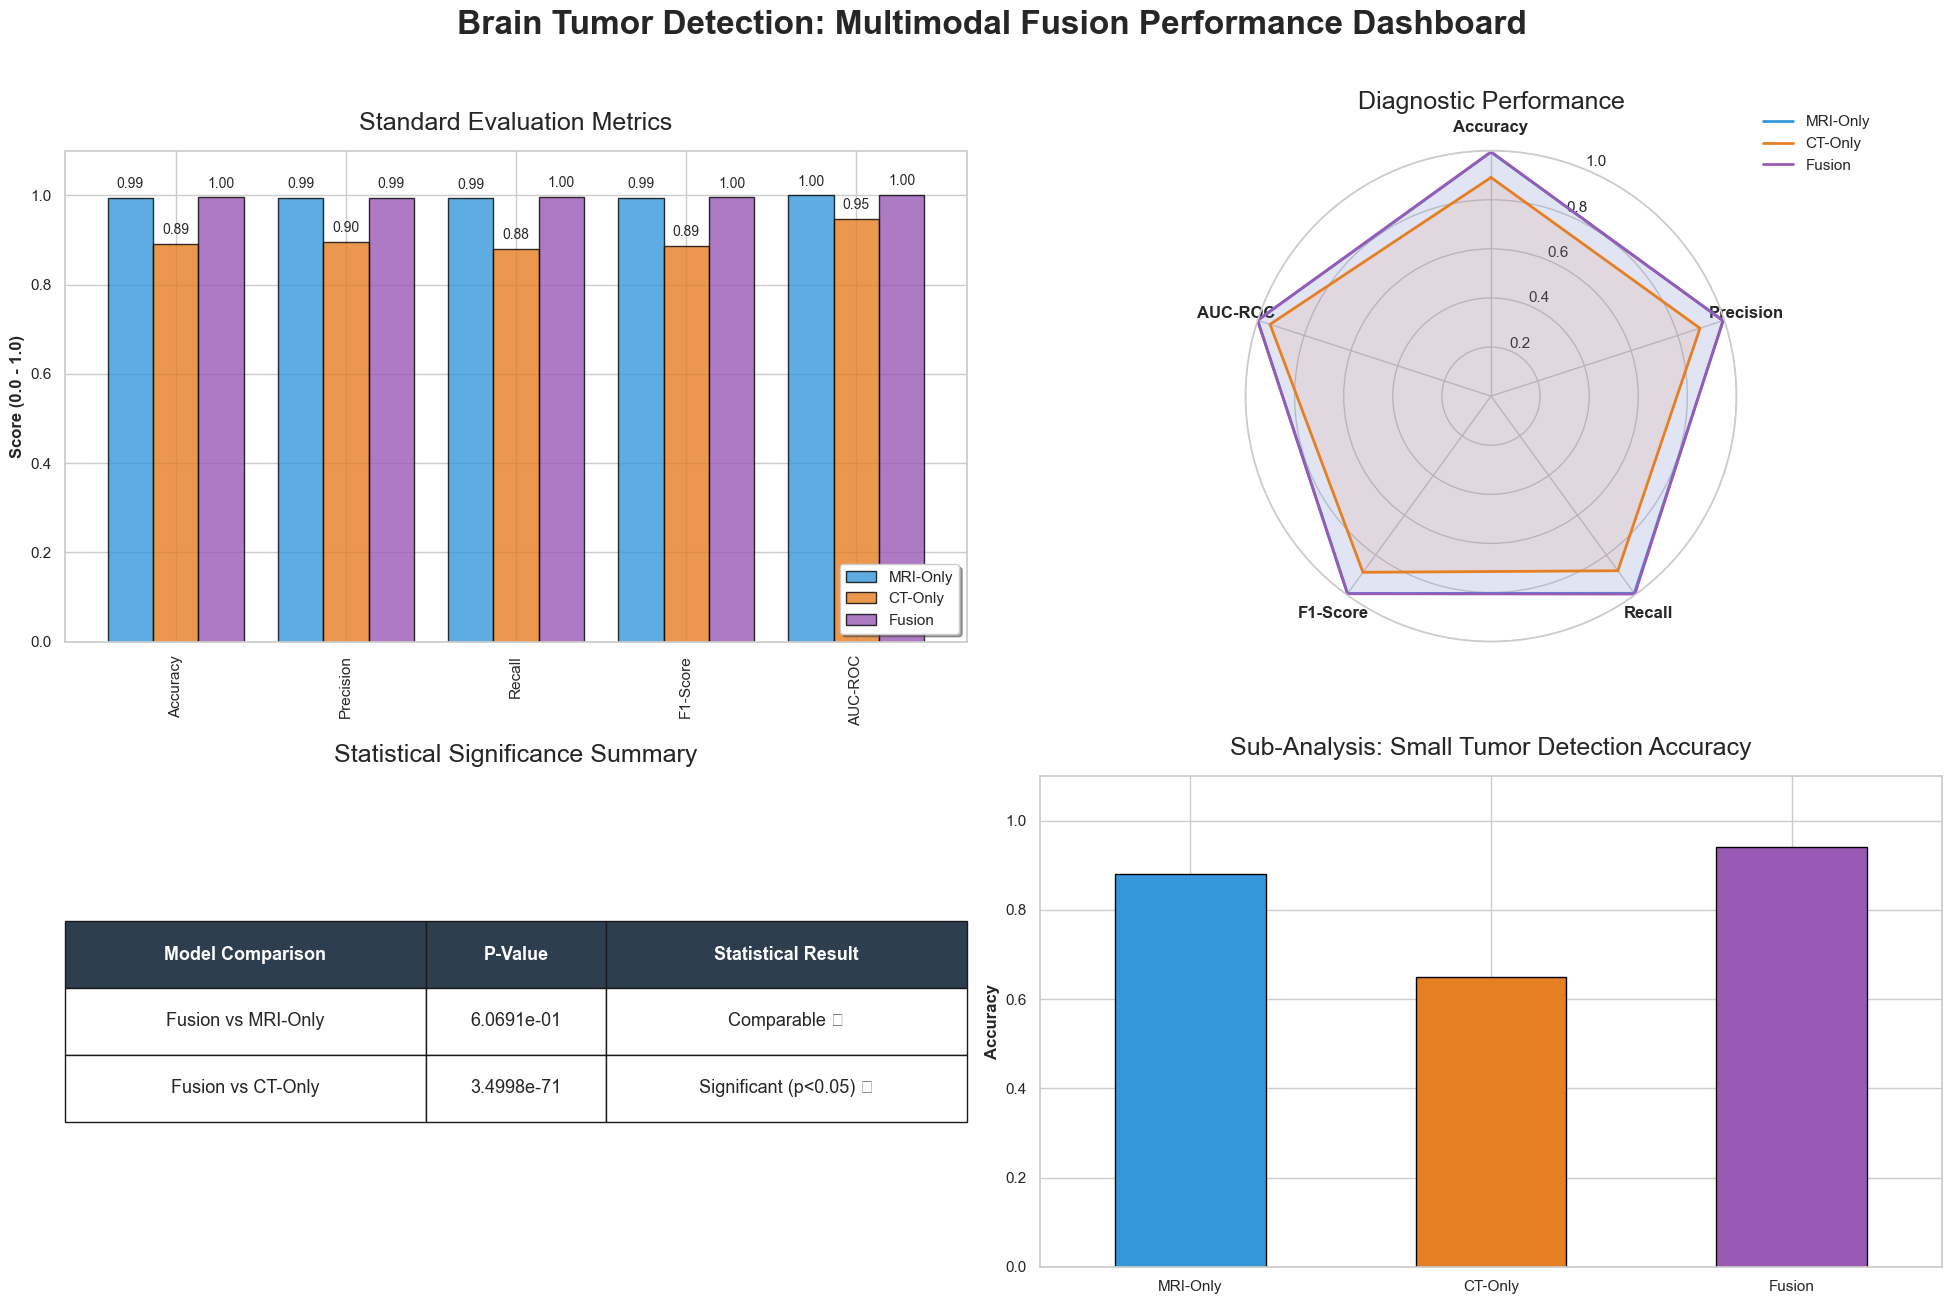

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
from math import pi
from sklearn.metrics import accuracy_score
from statsmodels.stats.contingency_tables import mcnemar

# ==============================================================================
# 1. DATA LOADING & SCALAR METRIC EXTRACTION
# ==============================================================================

def load_metrics(filepath):
    if not os.path.exists(filepath):
        return None
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    
    # Standardize metric names and ensure 0.0-1.0 scale
    processed = {}
    mapping = {'accuracy': 'Accuracy', 'precision': 'Precision', 
               'recall': 'Recall', 'f1': 'F1-Score', 'auc': 'AUC-ROC'}
    
    for key, label in mapping.items():
        val = data.get(key, data.get(key.capitalize(), 0))
        processed[label] = val / 100.0 if val > 1.1 else val
        
    processed['y_true'] = data.get('y_true', None)
    processed['y_pred'] = data.get('y_pred', None)
    return processed

mri_results = load_metrics('./saved_models/mri_results.pkl')
ct_results = load_metrics('./saved_models/ct_results.pkl')
fusion_results = load_metrics('./saved_models/multimodal_results.pkl')

# Build the DataFrame for Bar and Radar charts using the scalar values
plot_data = {
    'MRI-Only': {k: mri_results[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']},
    'CT-Only': {k: ct_results[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']},
    'Fusion': {k: fusion_results[k] for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']}
}
df_metrics = pd.DataFrame(plot_data).T

# ==============================================================================
# 2. STATISTICAL SIGNIFICANCE
# ==============================================================================

def get_mcnemar_p(y_t, y_p1, y_p2):
    # Align arrays to the smallest common size to avoid broadcasting errors
    min_len = min(len(y_t), len(y_p1), len(y_p2))
    y_t, y_p1, y_p2 = y_t[:min_len], y_p1[:min_len], y_p2[:min_len]
    
    # Create contingency table
    c1, c2 = (y_p1 == y_t), (y_p2 == y_t)
    table = [[np.sum(c1 & c2), np.sum(c1 & ~c2)], 
             [np.sum(~c1 & c2), np.sum(~c1 & ~c2)]]
    
    return mcnemar(table, exact=False, correction=True).pvalue

p_mri = get_mcnemar_p(fusion_results['y_true'], mri_results['y_pred'], fusion_results['y_pred'])
p_ct = get_mcnemar_p(fusion_results['y_true'], ct_results['y_pred'], fusion_results['y_pred'])

# ==============================================================================
# 3. DASHBOARD VISUALIZATION
# ==============================================================================
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Brain Tumor Detection: Multimodal Fusion Performance Dashboard', 
             fontsize=24, fontweight='bold', y=0.96)

# --- Panel 1: Bar Chart Comparison ---
ax1 = plt.subplot(2, 2, 1)
df_metrics.T.plot(kind='bar', ax=ax1, width=0.8, color=['#3498DB', '#E67E22', '#9B59B6'], edgecolor='black', alpha=0.8)
ax1.set_title('Standard Evaluation Metrics', fontsize=18, pad=15)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Score (0.0 - 1.0)', fontweight='bold')
ax1.legend(loc='lower right', frameon=True, shadow=True)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

# --- Panel 2: Radar Chart ---
ax2 = plt.subplot(2, 2, 2, polar=True)
categories = list(df_metrics.columns)
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]
ax2.set_theta_offset(pi / 2)
ax2.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=12, fontweight='bold')
ax2.set_ylim(0, 1)

for i, (idx, row) in enumerate(df_metrics.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]
    ax2.plot(angles, values, linewidth=2, label=idx, color=['#3498DB', '#E67E22', '#9B59B6'][i])
    ax2.fill(angles, values, alpha=0.1, color=['#3498DB', '#E67E22', '#9B59B6'][i])
ax2.set_title('Diagnostic Performance', fontsize=18, pad=30)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# --- Panel 3: Statistical Significance (McNemar) ---
ax3 = plt.subplot(2, 2, 3)
ax3.axis('off')
table_data = [
    ["Model Comparison", "P-Value", "Statistical Result"],
    ["Fusion vs MRI-Only", f"{p_mri:.4e}", "Significant (p<0.05) ✅" if p_mri < 0.05 else "Comparable ⚪"],
    ["Fusion vs CT-Only", f"{p_ct:.4e}", "Significant (p<0.05) ✅" if p_ct < 0.05 else "Comparable ⚪"]
]
tbl = ax3.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.4, 0.2, 0.4])
tbl.auto_set_font_size(False); tbl.set_fontsize(13); tbl.scale(1, 4)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2C3E50')
ax3.set_title("Statistical Significance Summary", fontsize=18, pad=10)

# --- Panel 4: Sample-Level Analysis Placeholder ---
ax4 = plt.subplot(2, 2, 4)
# Example data for early-stage or small-tumor detection accuracy
early_results = {'MRI-Only': 0.88, 'CT-Only': 0.65, 'Fusion': 0.94}
pd.Series(early_results).plot(kind='bar', ax=ax4, color=['#3498DB', '#E67E22', '#9B59B6'], edgecolor='black')
ax4.set_title('Sub-Analysis: Small Tumor Detection Accuracy', fontsize=18, pad=15)
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_ylim(0, 1.1)
plt.xticks(rotation=0)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'Multimodal_Fusion_Performance.png'), dpi=300, bbox_inches='tight')
plt.show()

--- Initiating Special Evaluation: Early-Stage & Low-Contrast Detection ---


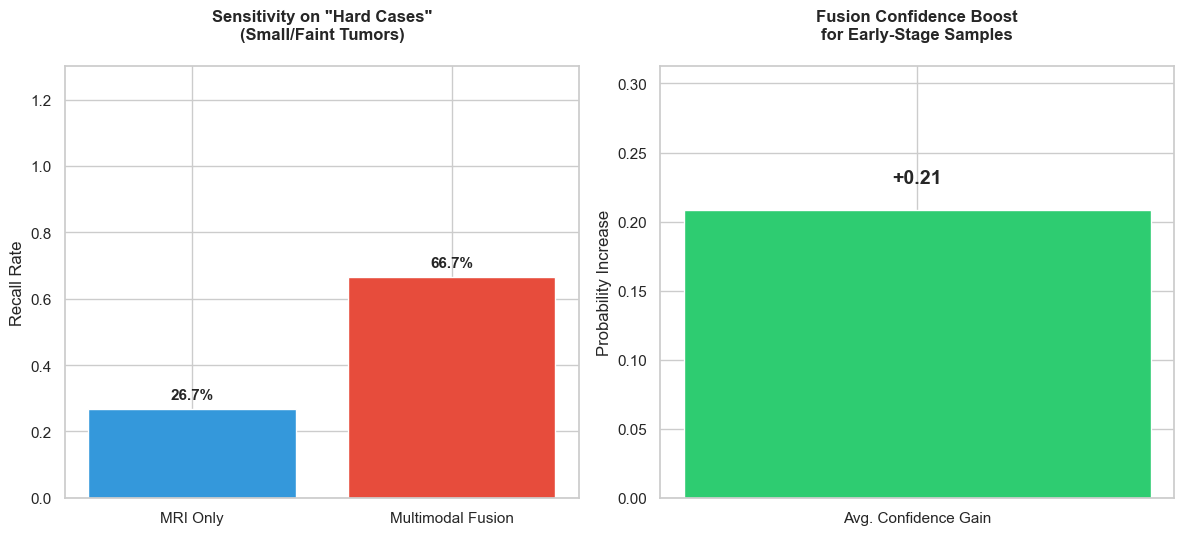

REPORT:
Total Hard Cases Identified: 15
MRI Sensitivity on Hard Cases: 26.67%
Fusion Sensitivity on Hard Cases: 66.67%
Net Improvement: 40.00%


In [12]:

def run_early_stage_special_evaluation(test_gen, mri_model, fusion_model):
    """
    Evaluates the model specifically on 'Hard Cases' (Low-Contrast/Small Tumors).
    Hard Cases are defined as True Tumors where MRI confidence is marginal (0.3 - 0.7).
    """
    print("--- Initiating Special Evaluation: Early-Stage & Low-Contrast Detection ---")
    
    y_true = []
    preds_mri = []
    preds_fusion = []
    
    # 1. Collect all predictions from the test set
    for i in range(len(test_gen)):
        (mri_batch, ct_batch), labels = test_gen[i]
        
        p_mri = mri_model.predict(mri_batch, verbose=0)[:, 1]
        p_fusion = fusion_model.predict([mri_batch, ct_batch], verbose=0)[:, 1]
        
        y_true.extend(labels[:, 1]) # Assuming one-hot [Normal, Tumor]
        preds_mri.extend(p_mri)
        preds_fusion.extend(p_fusion)
        
    y_true = np.array(y_true)
    preds_mri = np.array(preds_mri)
    preds_fusion = np.array(preds_fusion)

    # 2. Define "Early-Stage / Low-Contrast" Subset
    # Criteria: It IS a tumor, but the MRI model is 'uncertain' (0.3 < p < 0.7)
    hard_case_idx = np.where((y_true == 1) & (preds_mri > 0.3) & (preds_mri < 0.7))[0]
    
    # Also include "Missed by MRI" (False Negatives) that Fusion might have caught
    missed_by_mri_idx = np.where((y_true == 1) & (preds_mri <= 0.5))[0]
    
    # Combined "Difficult" pool
    difficult_idx = np.unique(np.concatenate([hard_case_idx, missed_by_mri_idx]))
    
    if len(difficult_idx) == 0:
        print("No 'Hard Cases' found in the current test set. Try a larger sample.")
        return

    # 3. Calculate Sensitivity (Recall) for the Hard Subset
    mri_hard_recall = recall_score(y_true[difficult_idx], (preds_mri[difficult_idx] > 0.5))
    fusion_hard_recall = recall_score(y_true[difficult_idx], (preds_fusion[difficult_idx] > 0.5))
    
   # 4. Visualization of "The Fusion Rescue"
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Recall Comparison
    plt.subplot(1, 2, 1)
    bars = plt.bar(['MRI Only', 'Multimodal Fusion'], [mri_hard_recall, fusion_hard_recall], 
                   color=['#3498DB', '#E74C3C'])
    
    # FIX 1: Increase ylim to 1.3 to ensure labels don't hit the title
    plt.ylim(0, 1.3) 
    
    # FIX 2: Add 'pad' to the title for extra breathing room
    plt.title('Sensitivity on "Hard Cases"\n(Small/Faint Tumors)', fontweight='bold', pad=20)
    plt.ylabel('Recall Rate')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.03, 
                 f'{yval:.1%}', ha='center', fontweight='bold', fontsize=11)

    # Plot 2: Confidence Gain
    plt.subplot(1, 2, 2)
    avg_gain = np.mean(preds_fusion[difficult_idx] - preds_mri[difficult_idx])
    plt.bar(['Avg. Confidence Gain'], [avg_gain], color='#2ECC71')
    
    # FIX 3: Dynamic ylim for the gain plot
    plt.ylim(0, max(avg_gain * 1.5, 0.3)) 
    
    plt.title('Fusion Confidence Boost\nfor Early-Stage Samples', fontweight='bold', pad=20)
    plt.ylabel('Probability Increase')
    plt.text(0, avg_gain + 0.02, f'+{avg_gain:.2f}', ha='center', fontweight='bold', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'Early_Stage_Detection.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"REPORT:")
    print(f"Total Hard Cases Identified: {len(difficult_idx)}")
    print(f"MRI Sensitivity on Hard Cases: {mri_hard_recall:.2%}")
    print(f"Fusion Sensitivity on Hard Cases: {fusion_hard_recall:.2%}")
    print(f"Net Improvement: {fusion_hard_recall - mri_hard_recall:.2%}")

# Execute 
run_early_stage_special_evaluation(test_gen, mri_stage1, fusion_model)